# B8 — Explicabilité SHAP : XGBoost sobre (B5) vs tuné (B7), horizon 24h

B7 (`05_tuning_xgboost.ipynb`) a amélioré le PR-AUC test de 0,4528 (XGBoost "sobre" B5) à
0,5218 (XGBoost tuné par Optuna) à l'horizon 24h. Cette comparaison répond à « le tuning
a-t-il amélioré le score ? » — ce notebook répond à une question différente : **le tuning
a-t-il changé ce que le modèle regarde ?**, via **SHAP** (SHapley Additive exPlanations).

Deux garde-fous :
- **Portée globale uniquement** : résumé sur l'ensemble du split test (importance moyenne
  par feature). Pas d'explication locale (une observation précise, ex. "pourquoi CETTE
  machine ?") ni de dependence plot dans cette première itération — hors périmètre, une
  extension possible sans remettre en cause cette base.
- **Comparaison par part normalisée et rang, jamais par valeur brute** : B7 est un modèle
  plus conservateur que B5 (learning_rate plus faible, arbres moins profonds/nombreux) — il
  produit donc mécaniquement des valeurs SHAP plus petites sur *toutes* les features, sans
  que ça signifie qu'il "regarde moins" les features. Comparer les valeurs brutes serait
  trompeur ; la comparaison utilise une part normalisée (somme = 1 par modèle) et le rang
  d'importance, invariants à cette différence d'échelle.

Prérequis : `03_gold.ipynb`/`indusense-gold` (le gold doit exister) et au moins un run
`indusense-tune` (`05_tuning_xgboost.ipynb`, pour les meilleurs hyperparamètres B7).

## 1. Calcul SHAP (les deux modèles, XGBoost sobre + tuné)

In [1]:
import time

from indusense.ml import explain

t0 = time.perf_counter()
meta = explain.run(horizon=24)
duree = time.perf_counter() - t0
print(f"run={meta['run_id']}  tuning_run={meta['tuning_run_id']}  temps={duree:.1f}s")

D:\ProjetsIA\AELION_Concevoir_Et_Implementer_Solution_IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run=202607081141  tuning_run=202607071556  temps=20.1s


## 2. Comment lire une valeur SHAP (avant les figures)

- **Ce que mesure SHAP** : pour chaque feature et chaque observation, sa contribution à
  l'écart entre la prédiction du modèle et sa prédiction moyenne — une décomposition
  additive de la prédiction, pas une corrélation.
- **Échelle : marge (log-odds), pas probabilité.** `TreeExplainer` (utilisé ici) calcule les
  valeurs SHAP dans l'espace de sortie brut du modèle XGBoost, avant la fonction logistique
  qui les convertirait en probabilité. Une valeur positive pousse la prédiction vers "à
  risque", une valeur négative vers "normal" — le **signe** et l'**ordre de grandeur relatif**
  sont interprétables directement, la valeur absolue ne se lit pas comme "+0,3 point de
  probabilité".
- **Direction (couleur) sur les figures de résumé** : rouge = valeur élevée de la feature
  pour cette observation, bleu = valeur faible. Un nuage rouge à droite de 0 = les valeurs
  élevées de cette feature poussent vers le risque.
- **Comparer B5 et B7 : jamais par hauteur brute.** Cf. garde-fou en introduction — B7 étant
  un modèle plus conservateur, ses valeurs SHAP brutes sont mécaniquement plus petites sur
  toutes les features. Seules la **part normalisée** (`importance_share`, somme = 1 par
  modèle) et le **rang** (`rank_b5`/`rank_b7`/`delta_rank`) sont comparables entre les deux
  modèles.
- **Portée globale uniquement** : les figures ci-dessous résument le comportement du modèle
  sur l'ensemble du test, pas une observation individuelle.

## 3. Tableau de comparaison (part normalisée + rang)

In [2]:
from pathlib import Path

import pandas as pd

comparison = pd.read_csv(Path(meta["chemin"]) / "comparaison_importance.csv")
display(comparison[["feature", "share_b5", "share_b7", "rank_b5", "rank_b7", "delta_rank"]])

,feature,share_b5,share_b7,rank_b5,rank_b7,delta_rank
0,time_since_last_incident_h,0.115617,0.403541,1,1,0
1,age_days,0.055516,0.102968,2,2,0
2,temperature_c_min_48h,0.027907,0.053531,6,3,3
3,temperature_c_min_24h,0.033864,0.052808,4,4,0
4,n_incidents_7d,0.026671,0.045091,7,5,2
5,time_since_last_maintenance_h,0.028268,0.042256,5,6,-1
6,voltage_mean_v,0.034390,0.039372,3,7,-4
7,pressure_bar,0.020804,0.035683,14,8,6
8,rotation_mean_rpm,0.011740,0.014416,33,9,24
9,temperature_c,0.008479,0.013553,37,10,27


## 4. Figures

Une sous-section par graphique : nature, comment l'utiliser, grille de lecture des
résultats réels de ce run.

### 4.1 Résumé SHAP — XGBoost sobre (B5)

**Nature** : nuage de points (échantillon aléatoire de 2000 observations test, graine 42,
sur les 19653 au total — pour la lisibilité ; l'importance moyenne, elle, est calculée sur
les 19653), un point par observation et par feature (les `top_n` features les plus
importantes). Couleur = valeur de la feature (rouge = élevée, bleu = faible), position
horizontale = contribution SHAP (marge/log-odds) à la prédiction de cette observation.

**Utilisation** : identifier à la fois l'importance d'une feature (dispersion horizontale)
et le sens de son effet (couleur du côté "pousse vers le risque").

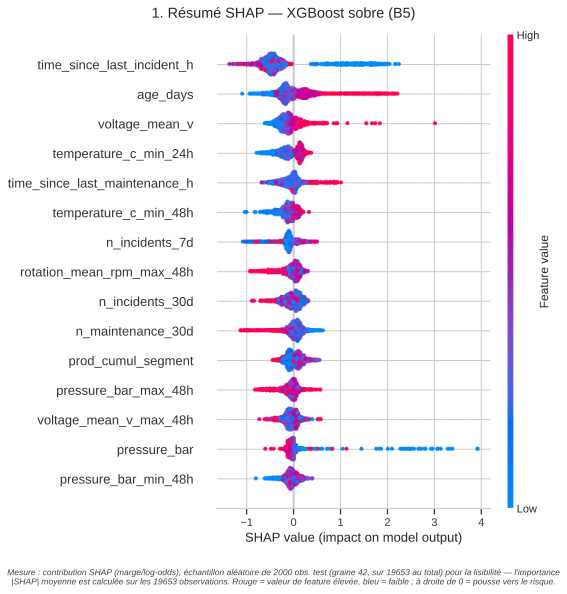

In [3]:
from IPython.display import SVG, display

display(SVG(filename=str(Path(meta["chemin"]) / "figures" / "01_summary_b5_sobre.svg")))

**Grille de lecture (ce run)**

| Observation | Interprétation |
|---|---|
| `time_since_last_incident_h` domine largement (part 11,6 %, rang 1) | Le signal le plus déterminant du modèle sobre : le temps écoulé depuis le dernier incident — cohérent avec l'intuition métier (usure/récidive) |
| `age_days` en 2e position (part 5,6 %) | L'ancienneté de la machine pèse nettement, mais loin derrière l'historique d'incidents récents |
| `voltage_mean_v`, `temperature_c_min_24h`, `time_since_last_maintenance_h` (rangs 3-5) | Un groupe de features capteur/maintenance d'importance comparable, aucune ne domine à elle seule |
| Le reste du top 15 (rang 6+) a des parts nettement plus faibles | La décision du modèle sobre repose sur un petit nombre de features (5 features = ~28 % de l'importance totale) plutôt que d'être diffuse |

### 4.2 Résumé SHAP — XGBoost tuné (B7)

**Nature** : même lecture que 4.1, pour le modèle tuné par Optuna (meilleurs
hyperparamètres du run `indusense-tune` le plus récent).

**Utilisation** : comparer visuellement quelles features dominent le nuage par rapport à
4.1 — une inspection qualitative, avant le tableau quantitatif normalisé (4.3/4.4).

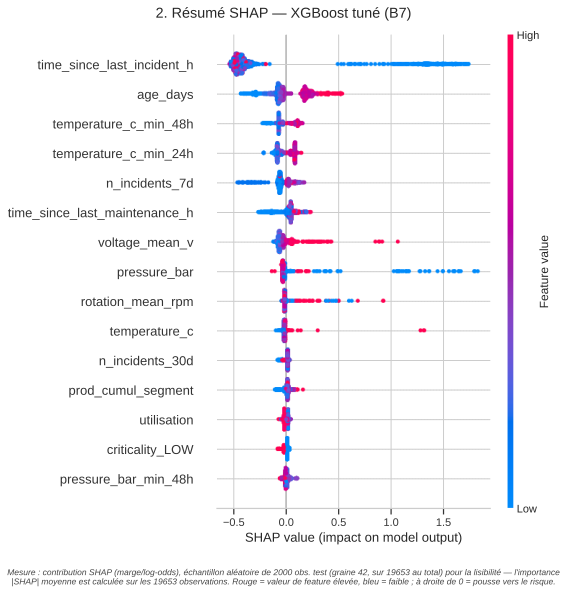

In [4]:
display(SVG(filename=str(Path(meta["chemin"]) / "figures" / "02_summary_b7_tune.svg")))

**Grille de lecture (ce run)**

| Observation | Interprétation |
|---|---|
| `time_since_last_incident_h` domine encore plus fortement (part 40,4 %, rang 1) | Contrairement à une hauteur brute (biaisée par l'échelle, cf. section 2), la **part** est comparable entre modèles : le tuning a **concentré** l'importance sur cette feature, elle ne s'est pas juste "rétrécie avec le reste" |
| `age_days` reste en 2e position (part 10,3 %) | Rang inchangé, mais part elle aussi doublée par rapport au sobre — même phénomène de concentration |
| `temperature_c_min_48h` entre dans le top 3 (part 5,3 %, monte du rang 6 au rang 3) | Une feature de dégradation à fenêtre longue (48h) gagne en priorité avec le tuning |
| Le top 2 seul capte plus de la moitié de l'importance totale (50,7 %) | Le modèle tuné est beaucoup plus concentré sur un petit nombre de signaux que le modèle sobre (dont le top 2 ne captait que 17,1 %) |

### 4.3 Comparaison d'importance (part normalisée)

**Nature** : barres horizontales groupées, part normalisée (`share_b5`/`share_b7`, somme = 1
par modèle) pour l'union des features les plus importantes des deux modèles — **pas les
valeurs brutes** (cf. garde-fou introduction/section 2 : un modèle plus conservateur aurait
mécaniquement des barres plus courtes partout, sans rapport avec l'attention réelle portée
à chaque feature).

**Utilisation** : comparer directement, feature par feature, le poids relatif accordé par
chaque modèle — une barre B7 nettement plus longue que B5 (ou l'inverse) sur une feature
signale un changement réel de priorité, pas un artefact d'échelle.

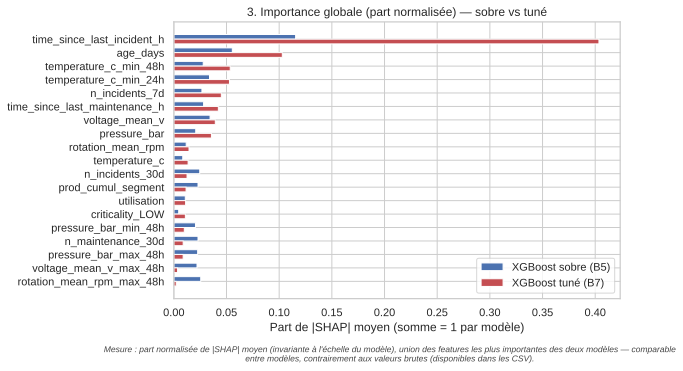

In [5]:
display(SVG(filename=str(Path(meta["chemin"]) / "figures" / "03_comparaison_importance.svg")))

**Grille de lecture (ce run)**

| Observation | Interprétation |
|---|---|
| Les barres B7 des rangs 1-2 sont nettement plus longues que B5 | Confirme la concentration observée en 4.2 : le tuning ne redistribue pas l'importance uniformément, il la recentre sur `time_since_last_incident_h`/`age_days` |
| `pressure_bar` : part quasi doublée (2,1 % -> 3,6 %), rang 14 -> 8 | Une feature de pression brute (pas une fenêtre glissante) gagne en priorité avec le tuning |
| `rotation_mean_rpm_max_48h` : part divisée par ~9 (2,6 % -> 0,2 %), rang 8 -> 39 | La feature qui perd le plus de terrain — le tuning s'appuie beaucoup moins sur ce maximum de rotation à 48h |
| La plupart des barres B7 hors top 5 sont visiblement plus courtes que B5 | Cohérent avec la concentration : moins de features se partagent une part significative de l'importance dans le modèle tuné |

### 4.4 Changement de rang d'importance (delta_rank)

**Nature** : barres horizontales signées, `delta_rank = rang_B5 - rang_B7` par feature,
triées par ampleur de changement. Vert = la feature est montée en priorité entre B5 et B7 ;
rouge = elle a descendu ; gris = rang inchangé.

**Utilisation** : la lecture la plus directe de la question posée par ce notebook — quelles
features ont changé de priorité avec le tuning, indépendamment de toute échelle de valeur.

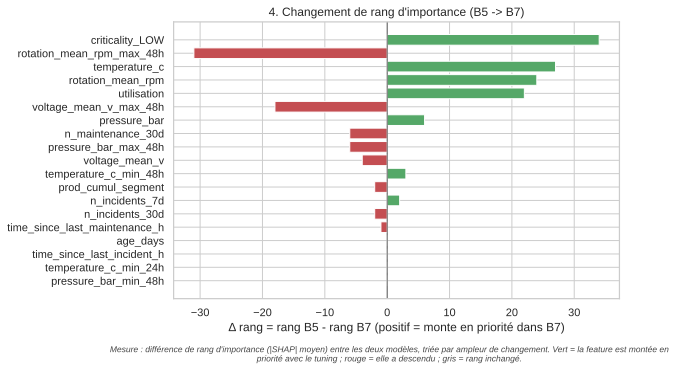

In [6]:
display(SVG(filename=str(Path(meta["chemin"]) / "figures" / "04_delta_rang.svg")))

**Grille de lecture (ce run)**

| Observation | Interprétation |
|---|---|
| `criticality_LOW` : plus forte hausse (delta +34, rang 48 -> 14) | Une feature catégorielle absente du top 15 du modèle sobre entre dans celui du modèle tuné — le tuning donne du poids à la criticité déclarée de la machine, pas seulement aux capteurs |
| `rotation_mean_rpm_max_48h` : plus forte baisse (delta -31, rang 8 -> 39) | À l'inverse, cette feature de dégradation (maximum de rotation sur 48h) perd nettement en priorité — le modèle tuné s'appuie moins sur ce signal |
| `voltage_mean_v_max_48h` : 2e plus forte baisse (delta -18) | Même tendance que ci-dessus sur une autre feature à fenêtre glissante de tension |
| La majorité des features ont un `delta_rank` modeste (proche de 0, gris/teintes claires) | Le cœur du classement (top 2, cf. 4.1-4.3) est stable ; les mouvements marqués concernent surtout des features de second plan |

## 5. Reproductibilité & suivi

- **Réentraînement déterministe, pas de rechargement MLflow** : les deux pipelines (B5
  sobre, B7 tuné) sont reconstruits et réentraînés sur le train directement par
  `explain.run()`, avec `random_state=42` fixe — déterministe bit-à-bit (à versions de
  librairies identiques) avec les modèles suivis par `training.py`/`tuning.py`, sans
  dépendre de la sérialisation MLflow.
- **Pas de tracking MLflow ici** : ce module ne produit aucun nouveau modèle, seulement des
  artefacts d'analyse (figures + CSV), déjà versionnés sous `artifacts/explain/<run_id>/`.
- **Provenance des hyperparamètres B7** : `meta["tuning_run_id"]` identifie le run
  `indusense-tune` dont les meilleurs hyperparamètres ont été repris (affiché dans la sortie
  de la cellule d'exécution, section 1) — toujours un tuning à l'horizon 24h (seul horizon
  tuné à ce jour).

➡️ **Conclusions**

- **Oui, le tuning a changé ce que le modèle regarde — pas juste son score.** `time_since_last_incident_h`
  reste la feature dominante dans les deux modèles (rang 1), mais sa part passe de 11,6 %
  (B5) à 40,4 % (B7) : le modèle tuné **concentre** sa décision sur un plus petit nombre de
  signaux (le top 2 capte 50,7 % de l'importance en B7, contre 17,1 % en B5).
- **Le cœur du classement est stable, les mouvements marqués sont en périphérie** :
  `time_since_last_incident_h`/`age_days` gardent les rangs 1-2 dans les deux modèles. Les
  changements les plus nets concernent des features de second plan : `criticality_LOW` entre
  dans le top 15 (rang 48 -> 14) et `rotation_mean_rpm_max_48h` en sort largement
  (rang 8 -> 39).
- **Rappel méthodologique** : ces lectures s'appuient sur la part normalisée et le rang, pas
  sur la hauteur brute des barres SHAP — un modèle plus conservateur (B7) aurait de toute
  façon des valeurs brutes plus petites partout, sans rapport avec un changement réel
  d'attention (cf. section 2).
- **Hors périmètre de ce notebook** : l'explication locale (pourquoi une machine précise est
  jugée à risque) et les dependence plots (effets de seuil sur une feature) restent des
  extensions possibles, non traitées dans cette première itération.